In [1]:
import os
import os.path as osp
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import dsrl.infos as dsrl_infos

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
DATA_PATH = "/home/returaj/Documents/research/offline_safe_rl/"

In [3]:
cmky_map = {
    "cornflowerblue": "#4F81BD",
    "orange": "#E69F00",
    "coral": "#D97662",
    "orchid": "#B57BB3",
    "olive": "#7A8F00",
    "slate": "#6C757D",
    "brown": "#8C564B",
    "vermillion": "#D55E00",
    "teal": "#009E73",
    "navy": "#1F3A5F",
    "cyan": "#56B4E9",
    "mustard": "#B79F00",
}

BASE_COLORS = ["black", cmky_map["cornflowerblue"], cmky_map["orange"], cmky_map["olive"],
               cmky_map["orchid"], cmky_map["slate"], cmky_map["vermillion"], cmky_map["brown"], 
               cmky_map["coral"],]

MARKERS = [
    None,
    "o",  # circle
    "s",  # square
    "D",  # diamond
    "p",  # pentagon
    "X",  # filled x
    "*",  # star
    "P",  # filled plus
    "h",  # hexagon1
    ">",  # triangle right
    "d",  # thin diamond
    "<",  # triangle left
    "+",  # plus
    "x",  # x
    "H",  # hexagon2
    "v",  # triangle down
    "^",  # triangle up
]

HATCH_PATTERNS = [None, '/', '\\', '.', 'o', '*', 'x', 'o', 'O', '.', '*']

In [4]:
def light_color(color, amount=0.7):
    try:
        c = mcolors.cnames[color]  # convert named color to hex
    except KeyError:
        c = color  # if it's not a named color, it might already be hex or RGB

    rgb = mcolors.to_rgb(c)  # convert to RGB format
    light_color = [(1 - amount) * channel + amount for channel in rgb]  # blend with white
    return light_color

In [5]:
EP = 1e-5

def normalize_reward(arr, baseline, env_name, scaled=False):
    env_name = env_name.replace("_", "")
    # max_reward = dsrl_infos.MAX_EPISODE_REWARD[env_name]
    min_reward = min(arr.min(), dsrl_infos.MIN_EPISODE_REWARD[env_name])
    max_reward = max(arr.max(), dsrl_infos.MAX_EPISODE_REWARD[env_name])
    arr = arr.clip(min=min_reward, max=max_reward)
    scale_rwd = (arr - min_reward) / (max_reward - min_reward)
    return scale_rwd if scaled else arr


def normalize_cost(arr, baseline, env_name, scaled=False):
    env_name = env_name.replace("_", "")
    min_cost = dsrl_infos.MIN_EPISODE_COST[env_name]
    max_cost = dsrl_infos.MAX_EPISODE_COST[env_name]
    arr = arr.clip(min=min_cost, max=max_cost)
    scale_cost = (arr - min_cost) / (max_cost - min_cost)
    return scale_cost if scaled else arr


def normalize_scaled_lowcost(arr, baseline, env_name):
    env_name = env_name.replace("_", "")
    min_cost = min(arr.min(), dsrl_infos.MIN_EPISODE_COST[env_name])
    max_cost = max(arr.max(), dsrl_infos.MAX_EPISODE_COST[env_name])
    arr = arr.clip(min=min_cost, max=max_cost)
    scaled_cost = (max_cost - arr) / (max_cost - min_cost)
    return scaled_cost

In [6]:
def load_data_as_array(hyperparams, algo, task, type):
    # load csv to dataframe
    path = f"{DATA_PATH}/{hyperparams}/{algo}/{task}/{type}"
    abs_filenames = sorted([osp.join(path, f) for f in os.listdir(path)])
    dfs = []
    for i, f in enumerate(abs_filenames):
        d = pd.read_csv(f)
        if "Wall time" in d.columns:
            d = d.drop(columns=["Wall time"])
        d = d.rename(columns={"Value": f"seed_{i}"})
        dfs.append(d)
 
    # join dataframes based on Step
    df = dfs[0]
    for d in dfs[1:]:
        df = df.join(d.set_index("Step"), on="Step", how="right")
    
    df = df.drop(columns=["Step"])
    df = df.reset_index(drop=True)
    for col in df.columns:
        avg = (df[col].shift(1) + df[col].shift(-1)) / 2
        df[col] = df[col].where(df[col].notna(), avg)
        if pd.isna(df.at[0, col]):
            df.at[0, col] = df.at[1, col]
        if pd.isna(df.at[len(df) - 1, col]):
            df.at[len(df) - 1, col] = df.at[len(df) - 2, col]
    
    # num_seeds X T
    arr = df.to_numpy().T
    return arr

In [7]:
def bootstrap_confidence_interval(data, n_bootstrap=1000, confidence_level=0.95):
    """
    Function to compute bootstrap confidence intervals for time-series data and plot the results.
    
    Parameters:
    data (list of array-like): List of n time-series datasets (arrays) of the same length.
    n_bootstrap (int): Number of bootstrap resamples.
    confidence_level (float): Confidence level for the interval (default is 0.95).
    
    Returns:
    mean, lower_bound, upper_bound: The lower and upper bounds of the confidence interval at each time step.
    """
    # Convert data to numpy array (shape: 5 x T, where T is the number of time steps)
    data = np.array(data)
    
    # Ensure all time-series are of the same length
    assert len(set([len(ts) for ts in data])) == 1, "All time-series must be of the same length!"
    
    # Number of time steps
    num_data, T = data.shape
    
    # Arrays to store bootstrap results
    bootstrapped_means = np.zeros((n_bootstrap, T))
    
    # Perform bootstrap resampling for each time step
    for i in range(n_bootstrap):
        # Resample with replacement from the num_data time-series at each time step
        resampled_indices = np.random.choice(num_data, (num_data,), replace=True)
        bootstrapped_means[i, :] = np.mean(data[resampled_indices], axis=0)
    
    # Compute the confidence interval at each time step
    alpha = (1 - confidence_level) / 2
    lower_bound = np.percentile(bootstrapped_means, 100 * alpha, axis=0)
    upper_bound = np.percentile(bootstrapped_means, 100 * (1 - alpha), axis=0)
    
    mean_time_series = np.mean(bootstrapped_means, axis=0)

    return mean_time_series, lower_bound, upper_bound

##### Line/Bar Plot for Return, Cost, CVaR Cost 20%

In [64]:
ALGOS = [("bc_union_kl", "BC-Union"), ("ilid_mse_nonorm", "ILID"), ("iqlearn", "IQLearn"), ("safecl_lfd", "SafeCL (LfD)"), ("safecl/embd_64_vtemp_1.0_piconst_0.9_wdecay_firsttrans/best_maps", "SafeCL (LfDnN)")]


In [65]:
def plot_confidence_interval(means, lowers, uppers, labels, colors, markers, title, xlabel, ylabel,
                             axis=None, is_ylabel=True, is_xlabel=True, is_title=True, 
                             facecolor="#fafafa", fontsize=24, half_timestep=True):
    ax = axis
    if axis is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    T = min([len(x) for x in means]) #len(means[0])
    x = (np.arange(T) + 1)
    x = x * 2 if half_timestep else x
    x = x / 100

    # set light background color
    ax.set_facecolor(facecolor)

    for m, l, u, label, c, mks in zip(means, lowers, uppers, labels, colors, markers):
        linestyle = '-'
        if np.all(m == l) == 1:
            linestyle = '--'
        ax.plot(x, m[:T], color=c, lw=2.0, label=label, linestyle=linestyle, marker=mks, markevery=7, markersize=5)
        ax.fill_between(x, l[:T], u[:T], color=light_color(c), alpha=0.4)
    
    if is_title:
        ax.set_title(title, fontsize=fontsize)
    if is_ylabel:
        ax.set_ylabel(ylabel, fontsize=fontsize)
    if is_xlabel:
        ax.set_xlabel(xlabel, fontsize=fontsize)

    ax.grid(visible=True, which='both', linestyle='--', linewidth=1.2, alpha=0.9)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)

    if axis is None:    
        return fig, ax
    else:
        return ax


def plot_bar_confidence_interval(means, lowers, uppers, labels, colors, title, xlabel, ylabel,
                                 axis=None, is_ylabel=True, is_xlabel=True, is_title=True,
                                 facecolor="#fafafa", fontsize=24):
    del colors, xlabel

    colors = ["orange", "green"]
    ax = axis
    if axis is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    last_m = [m[-1] for m in means]
    last_l = [l[-1] for l in lowers]
    last_u = [u[-1] for u in uppers]

    yerr = np.array([
        np.array(last_m) - np.array(last_l),
        np.array(last_u) - np.array(last_m)
    ])

    xgap = 1.5
    xpos = np.arange(len(labels))*xgap

    # set light background color
    ax.set_facecolor(facecolor)

    bars = ax.bar(xpos, last_m, yerr=yerr, capsize=8, color=colors, edgecolor='black')
    ax.set_xticks(xpos)

    if is_title:
        ax.set_title(title, fontsize=fontsize)
    if is_ylabel:
        ax.set_ylabel(ylabel, fontsize=fontsize)
    if is_xlabel:
        ax.set_xticklabels(labels, fontsize=fontsize)
        for bar, label in zip(bars, labels):
            bar.set_label(label)

    return ax

In [66]:
def generate_performance_figures(hyperparams, tasks):
    types = ("ep_reward", "ep_cost", "ep_worst_cost_0.2")
    num_tasks = len(tasks)
    figsize = (7, len(types)*1.585)
    single_fig, single_axs = plt.subplots(len(types), num_tasks, figsize=figsize, sharex='col')
    for y, task in enumerate(tasks):
        for x, type in enumerate(types):
            # preferred policy performance
            # data = load_data_as_array(hyperparams, "preferred_bc", task, type)
            # m, _, _ = bootstrap_confidence_interval(data)
            baseline = 0

            means, lowers, uppers, labels = [], [], [], []
            for a, suffix in ALGOS:
                data = load_data_as_array(hyperparams, a, task, type)
                m, l, u = bootstrap_confidence_interval(data)
                if a == "preferred_bc":
                    m = l = u = np.ones(50) * baseline
                if type == "ep_reward":
                    m, l, u = (normalize_reward(r, baseline, task) for r in (m, l, u))
                else:
                    m, l, u = (normalize_cost(c, baseline, task) for c in (m, l, u))
                means.append(m)
                lowers.append(l)
                uppers.append(u)
                labels.append(suffix)
            colors = BASE_COLORS[1:len(labels)] + [BASE_COLORS[-1]]
            markers = MARKERS[1:len(labels)] + [MARKERS[-1]]
            if type == "ep_cost":
                ylabel = "Normalized Cost"
            elif type == "ep_reward":
                ylabel = "Normalized Return"
            else:
                ylabel = "Normalized CVaR Cost"

            ax = plot_confidence_interval(means, lowers, uppers, labels=labels,
                                          colors=colors, markers=markers, title=task.replace("_", " "), 
                                          xlabel="training steps " + r"$ \, (\times 10^6)$",
                                          ylabel=ylabel, axis=single_axs[x, y], is_ylabel=y==0,
                                          is_xlabel=x==2, is_title=x==0, fontsize=9)

    plt.subplots_adjust(hspace=0.15) 
    return single_fig, single_axs

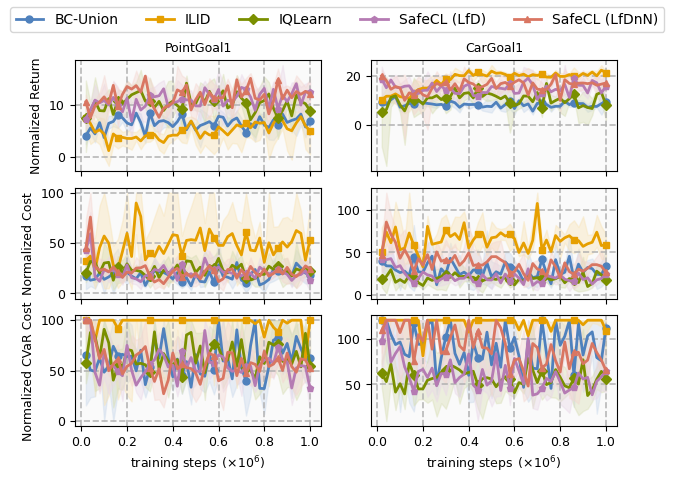

In [67]:
hyperparams = "neg_union_full/only_for_reporting"

key = "performance_comparison"
tasks = ['PointGoal1', "CarGoal1",]
# tasks = ['PointCircle2', "CarCircle2",]
# tasks = [ "AntVelocity", "SwimmerVelocity"]
# tasks = ["Walker2dVelocity", "HopperVelocity",]
# tasks = ["DroneRun", "DroneCircle",]
# tasks = ["AntRun", "AntCircle"]


fig, ax = generate_performance_figures(hyperparams, tasks)
handles, labels = ax[0, 0].get_legend_handles_labels()
# Create a single legend for all subplots
fig.legend(handles, labels, loc='upper center', ncol=len(ALGOS), fontsize=10)
# fig.tight_layout()

##### Line Plot F-$\beta$ score

In [ ]:
##### Value based policy learning #####

# ALGOS = [("bc_union_kl", "BC-Union"), ("ilid_mse_nonorm", "ILID"), ("iqlearn", "IQLearn"), ("safecl_lfd/value", "SafeCL (value LfD)"),]

# ALGOS = [("bc_union_kl", "BC-Union"), ("ilid_mse_nonorm", "ILID"), ("iqlearn", "IQLearn"), ("safecl/embd_64_vtemp_1.0_piconst_0.9_wdecay_firsttrans/best_maps", "SafeCL (value LfDnN)")]

# ALGOS = [("bc_union_kl", "BC-Union"), ("safedice", "SafeDICE"), ("uniq", "UNIQ"), ("safecl_lfn/value", "SafeCL (value LfN)")]

# ALGOS = [("bc_union_kl", "BC-Union"), ("safedice", "SafeDICE"), ("uniq", "UNIQ"), ("safecl/embd_64_vtemp_1.0_piconst_0.9_wdecay_firsttrans/best_maps", "SafeCL (value LfDnN)")]

# ALGOS = [("safedice", "SafeDICE (LfN)"), ("uniq", "UNIQ (LfN)"), ("ipl", "IPL (LfDnN)"), ("osil", "OSIL (LfDnN)"), ("safecl/embd_64_vtemp_1.0_piconst_0.9_wdecay_firsttrans/best_maps", "SafeCL (value LfDnN)"),]


In [8]:
##### Trajectory based policy learning #####

# ALGOS = [("bc_union_kl", "BC-Union"), ("ilid_mse_nonorm", "ILID"), ("iqlearn", "IQLearn"), ("safecl_lfd/traj", "SafeCL (value LfD)"),]

ALGOS = [("bc_union_kl", "BC-Union"), ("ilid_mse_nonorm", "ILID"), ("iqlearn", "IQLearn"), ("safecl/embd_64_piconst_0.9_wdecay_fulltrans/best_maps", "SafeCL (value LfDnN)")]

# ALGOS = [("bc_union_kl", "BC-Union"), ("safedice", "SafeDICE"), ("uniq", "UNIQ"), ("safecl_lfn/traj", "SafeCL (value LfN)")]

# ALGOS = [("bc_union_kl", "BC-Union"), ("safedice", "SafeDICE"), ("uniq", "UNIQ"), ("safecl/embd_64_piconst_0.9_wdecay_fulltrans/best_maps", "SafeCL (traj LfDnN)")]

# ALGOS = [("safedice", "SafeDICE (LfN)"), ("uniq", "UNIQ (LfN)"), ("ipl", "IPL (LfDnN)"), ("osil", "OSIL (LfDnN)"), ("safecl/embd_64_piconst_0.9_wdecay_fulltrans/best_maps", "SafeCL (traj LfDnN)"),]

In [9]:
# ALGOS = [("safecl_il_noreg", "SafeCL (wo/ reg)"), ("safecl_il", "SafeCL (w/ reg)")]

# ALGOS = [("safecl/embd_64_vtemp_1.0_piconst_0.9_wdecay_firsttrans/batch_64_pitemp_0.15/constant_projection", "SafeCL (0.15)"), ("safecl/embd_64_vtemp_1.0_piconst_0.9_wdecay_firsttrans/batch_64_pitemp_0.2/constant_projection", "SafeCL (0.2)"), ("safecl/embd_64_vtemp_1.0_piconst_0.9_wdecay_firsttrans/batch_64_pitemp_0.33/constant_projection", "SafeCL (0.33)"),]

# ALGOS = [("safecl/embd_64_vtemp_1.0_piconst_0.9_wdecay_firsttrans/batch_64_pitemp_0.2/model_projection", "SafeCL (model)"), ("safecl/embd_64_vtemp_1.0_piconst_0.9_wdecay_firsttrans/batch_64_pitemp_0.2/no_projection", "SafeCL (no)"), ("safecl/embd_64_vtemp_1.0_piconst_0.9_wdecay_firsttrans/batch_64_pitemp_0.2/constant_projection", "SafeCL (constant)"),]

# ALGOS = [("safemil/batch_4_bag_32", "SafeMIL"),  ("safecl/embd_64_vtemp_1.0_piconst_0.9_wdecay_firsttrans/best_maps", "SafeCL (constant)"),]

# ALGOS = [("safecl/embd_64_piconst_0.9_wdecay_fulltrans/best_maps", "SafeCL (traj)"), ("safecl/embd_64_vtemp_1.0_piconst_0.9_wdecay_firsttrans/best_maps", "SafeCL (value)"),]

# ALGOS = [("safecl/embd_64_piconst_0.9_wdecay_fulltrans/batch_64_pitemp_0.15/constant_projection", "SafeCL (0.15)"), ("safecl/embd_64_piconst_0.9_wdecay_fulltrans/batch_64_pitemp_0.2/constant_projection", "SafeCL (0.2)"), ("safecl/embd_64_piconst_0.9_wdecay_fulltrans/batch_64_pitemp_0.33/constant_projection", "SafeCL (0.33)"),]

In [10]:
def estimate_fbetas(data, cost_betas):
    # data: 2 X seed X T
    # betas: list
    # return: num_betas X seed X T
    
    data_betas = []
    for beta in cost_betas:
        # seed X T
        r, c = data[0], data[1]
        fbeta = ((1 + beta**2) * c * r) / (beta**2 * r + c).clip(EP)
        data_betas.append(fbeta)
    
    # num_betas X seed X T
    data_betas = np.array(data_betas)
    return data_betas


def plot_error_linebars(means, lowers, uppers, labels, title, betas, colors, markers, axis, fontsize):
    num_algos, _ = means.shape
    
    for i in range(num_algos):
        m, l, u = means[i], lowers[i], uppers[i]
        label, color, marker = labels[i], colors[i], markers[i]
        
        yerr_lower, yerr_upper = m - l, u - m
        yerr = np.array([yerr_lower, yerr_upper])
        
        axis.errorbar(
            x = betas,
            y = m,
            yerr=yerr,
            label=label,
            color=color,
            ecolor=color,
            marker=marker,
            capsize=5,
            linestyle='-',
            linewidth=2,
            alpha=0.8
        )
    
    axis.set_title(title, fontsize=fontsize)
    axis.set_xlabel(r"$\beta$", fontsize=fontsize)
    axis.set_ylabel(r"F$\beta$-score", fontsize=fontsize)
    axis.set_xticks(betas)  
    axis.grid(True, alpha=0.3)
    
    return axis

In [11]:
def generate_fbeta_figures(hyperparams, tasks, cost_betas, plot_type='combined'):
    num_y = 1 if plot_type == 'combined' else len(cost_betas)
    num_x = len(tasks)

    height = 2.5 if num_y == 1 else num_y * 1.8
    figsize = (6, height)
    single_fig, single_axs = plt.subplots(num_y, num_x, figsize=figsize, sharex='col')

    for y, task in enumerate(tasks):
        # num_algos X betas X T
        algo_mean_betas, algo_lower_betas, algo_upper_betas = [], [], []
        # num_algos
        labels = []
        for a, suffix in ALGOS:

            reward_cost_data = []
            for type in ("ep_reward", "ep_cost",):
                # preferred policy performance
                # data = load_data_as_array(hyperparams, "preferred_bc", task, type)
                # m, _, _ = bootstrap_confidence_interval(data)
                baseline = 0

                # seed X T
                data = load_data_as_array(hyperparams, a, task, type)
                if type == "ep_reward":
                    data = normalize_reward(data, baseline, task, scaled=True)
                else:
                    data = normalize_scaled_lowcost(data, baseline, task)
                reward_cost_data.append(data)

            # num_betas X seed X T
            data_betas = estimate_fbetas(reward_cost_data, cost_betas)
            # num_betas X T
            mean_betas, lower_betas, upper_betas = [], [], []
            for data in data_betas:
                # T
                m, l, u = bootstrap_confidence_interval(data)
                mean_betas.append(m); lower_betas.append(l); upper_betas.append(u)

            labels.append(suffix)
            algo_mean_betas.append(mean_betas)
            algo_lower_betas.append(lower_betas)
            algo_upper_betas.append(upper_betas)

        # num_algos X betas X T
        algo_mean_betas = np.array(algo_mean_betas)
        algo_lower_betas = np.array(algo_lower_betas)
        algo_upper_betas = np.array(algo_upper_betas)

        # num_algos
        colors = BASE_COLORS[2:len(labels)+1] + [BASE_COLORS[-1]]
        markers = MARKERS[2:len(labels)+1] + [MARKERS[-1]]

        if plot_type == 'combined':
            # num_algos X betas
            algo_mean = algo_mean_betas[:, :, -1]
            algo_lower = algo_lower_betas[:, :, -1]
            algo_upper = algo_upper_betas[:, :, -1]

            # # num_algos X betas
            # means, stds = algo_mean_betas.min(axis=-1), algo_mean_betas.std(axis=-1)
            # algo_mean, algo_lower, algo_upper = means, means - stds, means + stds

            _ = plot_error_linebars(
                algo_mean, algo_lower, algo_upper, labels, task, cost_betas, colors, markers, single_axs[y], fontsize=9,
            )

        elif plot_type == 'full':
            for i, beta in enumerate(cost_betas):
                means, lowers, uppers = algo_mean_betas[:,i, :], algo_lower_betas[:, i, :], algo_upper_betas[:, i, :]
                axis = single_axs[y] if num_y == 1 else single_axs[i, y]
                _ = plot_confidence_interval(means, lowers, uppers, labels=labels,
                                              colors=colors, markers=markers, title=task.replace("_", " "), 
                                              xlabel="training steps " + r"$ \, (\times 10^6)$",
                                              ylabel=beta, axis=axis, is_ylabel=y==0,
                                              is_xlabel=i==len(cost_betas), is_title=i==0, fontsize=9)

    plt.subplots_adjust(hspace=0.15) 
    return single_fig, single_axs

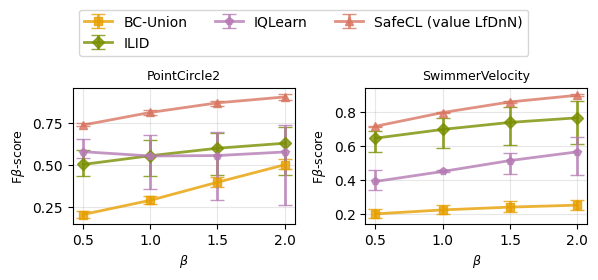

In [15]:
hyperparams = "neg_union_full/only_for_reporting"

key = "performance_comparison"
plot_type = "combined"
cost_betas = [0.5, 1.0, 1.5, 2.0]

# tasks = ['PointGoal1', "CarGoal1",]
tasks = ['PointCircle2', "SwimmerVelocity",]
# tasks = [ "AntVelocity", "SwimmerVelocity"]
# tasks = ["Walker2dVelocity", "HopperVelocity",]
# tasks = ["DroneRun", "DroneCircle",]
# tasks = ["AntRun", "AntCircle"]


fig, ax = generate_fbeta_figures(hyperparams, tasks, cost_betas, plot_type)
single_ax = ax[0] if plot_type == 'combined' else ax[0, 0]
handles, labels = single_ax.get_legend_handles_labels()

# 1. Compress the subplots area tightly to the top 92% of the canvas
fig.tight_layout(rect=[0, 0, 1, 0.92])

# Create a single legend for all subplots
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.89),  ncol=3, fontsize=10)
